***Ejercicio 2 — Segmentación de clientes***

Contexto: Una tienda quiere segmentar clientes según edad y gasto mensual.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [2]:
X = np.array([
    [20, 100],
    [22, 120],
    [23, 140],
    [45, 700],
    [46, 750],
    [48, 720],
    [60, 1500],
    [62, 1600]
])

clientes = [
    'C1', 'C2', 'C3',
    'C4', 'C5', 'C6',
    'C7', 'C8'
]

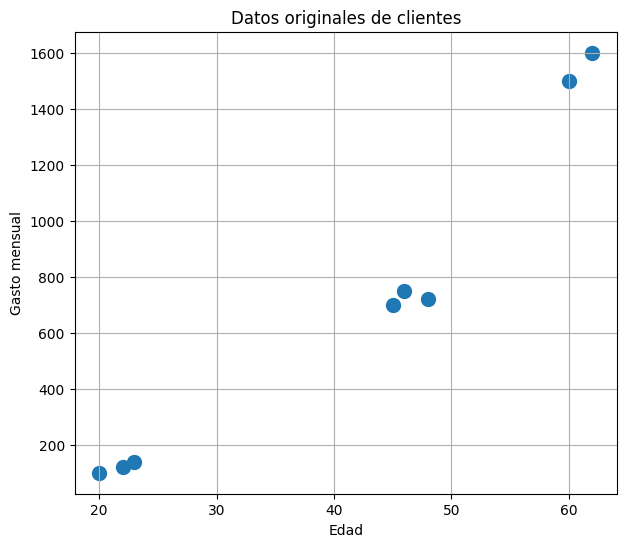

In [4]:
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], s=100)
plt.title('Datos originales de clientes')
plt.xlabel('Edad')
plt.ylabel('Gasto mensual')
plt.grid(True)
plt.show()

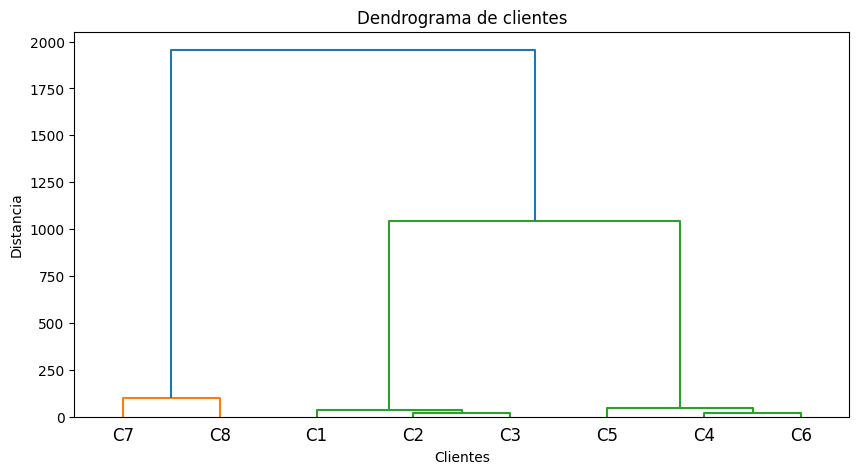

In [5]:
Z = linkage(X, method='ward')
plt.figure(figsize=(10,5))
dendrogram(
    Z,
    labels=clientes
)

plt.title('Dendrograma de clientes')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.show()


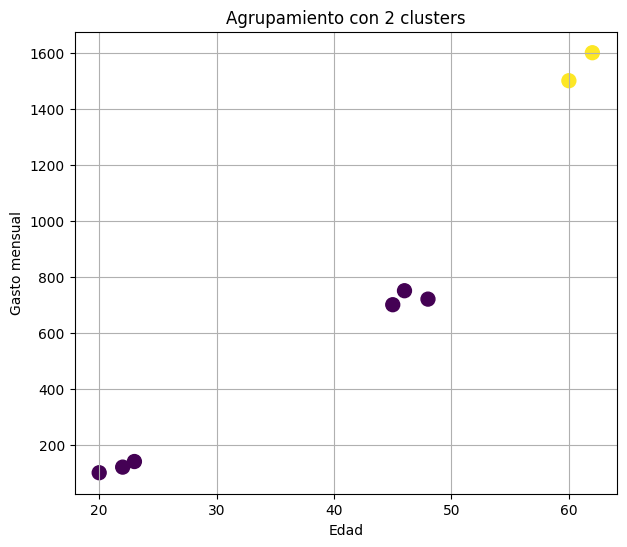

In [6]:
modelo_2 = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

clusters_2 = modelo_2.fit_predict(X)
plt.figure(figsize=(7,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters_2,
    s=100
)

plt.title('Agrupamiento con 2 clusters')
plt.xlabel('Edad')
plt.ylabel('Gasto mensual')
plt.grid(True)
plt.show()

In [9]:
print("clusters con 2 grupos:")
for cliente, cluster in zip(clientes, clusters_2):
    print(cliente, "-> cluster", cluster)

clusters con 2 grupos:
C1 -> cluster 0
C2 -> cluster 0
C3 -> cluster 0
C4 -> cluster 0
C5 -> cluster 0
C6 -> cluster 0
C7 -> cluster 1
C8 -> cluster 1


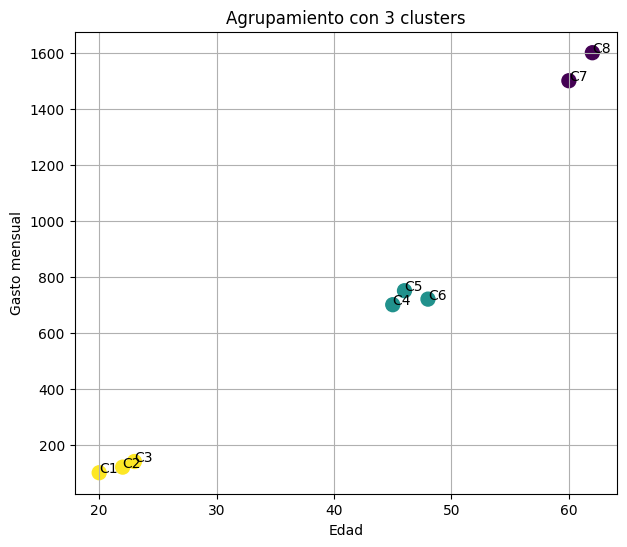

In [7]:
modelo_3 = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

clusters_3 = modelo_3.fit_predict(X)
plt.figure(figsize=(7,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters_3,
    s=100
)

for i, txt in enumerate(clientes):
    plt.annotate(txt, (X[i,0], X[i,1]))

plt.title('Agrupamiento con 3 clusters')
plt.xlabel('Edad')
plt.ylabel('Gasto mensual')
plt.grid(True)
plt.show()

In [8]:
print("clusters con 3 grupos:")
for cliente, cluster in zip(clientes, clusters_3):
    print(cliente, "-> cluster", cluster)

clusters con 3 grupos:
C1 -> cluster 2
C2 -> cluster 2
C3 -> cluster 2
C4 -> cluster 1
C5 -> cluster 1
C6 -> cluster 1
C7 -> cluster 0
C8 -> cluster 0


**¿Qué clientes parecen más similares?**

C1, C2 y C3
Porque tienen edades jóvenes y gastos bajos.
C4, C5 y C6
Porque tienen edades medias y gastos intermedios.
C7 y C8
Porque tienen mayor edad y gastos muy altos.

**¿Qué grupos naturales identifica el algoritmo?**

El algoritmo identifica 3 grupos principales:

Clientes jóvenes con bajo gasto.
Clientes adultos con gasto medio.
Clientes mayores con gasto alto.

**¿Qué representa cada cluster desde el punto de vista comercial?**

Cluster 1:
Clientes economicos o nuevos compradores.
Cluster 2:
Clientes frecuentes con capacidad media de compra.
Cluster 3:
Clientes premium o de alto valor para la tienda.

**¿Cuál sería una estrategia de marketing para cada grupo?**

Cluster 1:
Promociones, descuentos y ofertas económicas.
Cluster 2:
Programas de fidelización y paquetes especiales.
Cluster 3:
Atención personalizada, productos premium y beneficios exclusivos.

**¿Por qué el algoritmo agrupa ciertos clientes?**

Porque el algoritmo mide la similitud entre edad y gasto mensual y los clientes con características parecidas tienen menor distancia entre ellos y se agrupan solos.
